## Example analysis workflow — from raw data to fitted, colour-resolved puncta (NR4A PAINT, S. aureus)

Worked example of the full single-molecule analysis pipeline on a real acquisition
(Ximea Bayer camera), rather than simulated data: an NR4A exchange-PAINT
super-resolution sample of S. aureus (`Saureus_PAINT/50ms_70p_515_LP515_bp650_200_2`).
Like the SuperRes ATTO655/Cy3B version of this notebook
(`FigureSI_ExampleAnalysisWorkflow_SuperRes.ipynb`), this is a single-position acquisition
with fitting (and drift-correction/linking) already run end-to-end and saved to
`Localisations_Undrifted_Linked.h5` -- so this notebook loads those existing fit results
directly rather than re-running spot detection.

**Figure 2**: `N_PUNCTA` example puncta (user-controllable, `ROI_SIZE` pixels each), one
per column, rows = raw punctum / per-pixel fitting weights / reconstructed PSF fit (red X
= recovered position) / fit residual / recovered spectral signature (per-channel
amplitude fraction). Unlike the two-fixed-dye SuperRes template, there's no narrow `A_R`
band restriction in the candidate filter below -- NR4A's emission colour varies
continuously with local dye environment, so there's no single "other dye" band to
exclude here; candidates are instead selected purely on fit-quality criteria
(chi_sqr/photons/background_photons), tuned to this dataset's own distribution.

Figure 2 does not re-fit anything: it picks `N_PUNCTA` individual single-frame
localisations directly from the loaded fits, then re-renders everything downstream
straight from the raw data (see "Multi-file raw data handling" below) -- the same
building blocks the production pipeline uses (`SR_Functions.SuperRes_Functions`,
`ImageAnalysisFunctions.fit_puncta_parallel_method` with `FittingStrategy.STANDARD_DATA`).

In [1]:
import logging
logging.basicConfig(level=logging.WARNING, format='%(name)s — %(levelname)s — %(message)s')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import re
import time
import types
import tifffile
from pathlib import Path

from pyS3M import IOFunctions, SR_Functions, MaskFunctions, sCMOSFunctions, PlottingBase
# Bare import (not `from src.ImageAnalysisFunctions import ...`) -- see claude/TODO.md's
# note on the dual-import module-identity trap: SR_Functions bare-imports
# ImageAnalysisFunctions internally, so importing it the same way here keeps
# FittingStrategy/FittingConstants consistent with what SR_Functions uses.
from pyS3M.ImageAnalysisFunctions import FittingStrategy, Image_Analysis_Functions
import pyS3M.gaussoptfuncs as gaussoptfuncs
import pyS3M.render as render

IO       = IOFunctions.IO_Functions()
SupRes_F = SR_Functions.SuperRes_Functions(camera="ximea")
M_F      = MaskFunctions.Mask_Functions()
sCMOS    = sCMOSFunctions.sCMOS_Functions()
IAF      = Image_Analysis_Functions()
plotter  = PlottingBase.PublicationPlotter()

FIGURE_DIR = Path('/home/jbeckwith/Documents/Chemistry/Lee/Papers/Multicolour/SI/ExampleAnalysisWorkflow_SaureusPAINT/')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

pyS3M.Constants — INFO — Logging to file: /home/jbeckwith/Documents/Chemistry/Lee/Code/Python/pyS3M/logs/pyS3M.Constants_20260801_122945.log


In [29]:
# ── User-controllable parameters ─────────────────────────────────────────────
DATA_DIR = "/media/jbeckwith/Ezra Seagat/Saureus_PAINT/50ms_70p_515_LP515_bp650_200_2/"

ROI_SIZE       = 12   # ROI (pixels) cropped around each punctum for Figure 2
N_PUNCTA       = 6    # number of example puncta to show in Figure 2
SELECTION_SEED = 8    # random seed controlling which fitted puncta are shown

# Figure 2 candidate-selection quality filter, tuned to THIS dataset's own
# chi_sqr/photons/background_photons distribution (not copied from the
# SuperRes/QDots templates' own datasets). No A_R band restriction here (unlike
# the two-fixed-dye SuperRes template): this dye's emission colour varies
# continuously with local environment, so there's no single "other dye" band to
# exclude -- candidates are selected purely on fit-quality criteria.
CHI_SQR_MAX          = 1.5
PHOTON_BG_MIN        = 40.0
PHOTON_BG_MAX        = 50.0
MIN_PHOTONS_OVERVIEW = 1500
MAX_PHOTONS_OVERVIEW = 2200
A_R_min = 0.63
A_R_max = 0.65

# base_prefix derived from an actual metadata file present in DATA_DIR, rather
# than assumed to match DATA_DIR's own folder name (which the MicroManager save
# name at acquisition time need not match).
_meta_candidates = sorted(Path(DATA_DIR).glob('*_MMStack_Default_metadata.txt'))
if not _meta_candidates:
    raise FileNotFoundError(f'No *_MMStack_Default_metadata.txt found in {DATA_DIR}')
base_prefix = _meta_candidates[0].name[:-len('_MMStack_Default_metadata.txt')]

H5_FILE = os.path.join(DATA_DIR, "Localisations.h5")
META = os.path.join(DATA_DIR, f"{base_prefix}_MMStack_Default_metadata.txt")
print(f'base_prefix: {base_prefix}')
print(f'Localisations file: {H5_FILE}')

base_prefix: 50ms_70p_515_LP515_bp650_200_2
Localisations file: /media/jbeckwith/Ezra Seagat/Saureus_PAINT/50ms_70p_515_LP515_bp650_200_2/Localisations.h5


In [30]:
# ── Ximea camera calibration (real calibration maps, cropped to this acquisition's ROI) ─
CAL_DIR = '../../../Camera_Calibrations/Ximea_Camera/'
gain      = IO.read_tiff(os.path.join(CAL_DIR, 'gain.tif'))
offset    = IO.read_tiff(os.path.join(CAL_DIR, 'offset.tif'))
variance  = IO.read_tiff(os.path.join(CAL_DIR, 'variance.tif'))
readnoise = IO.read_tiff(os.path.join(CAL_DIR, 'readnoise.tif'))
rqe       = IO.read_tiff(os.path.join(CAL_DIR, 'rqe.tif'))

start_x, start_y, width, height = IO.metadata_reader_imageJ(META)
gain_c      = gain[start_y:start_y + height, start_x:start_x + width]
offset_c    = offset[start_y:start_y + height, start_x:start_x + width]
variance_c  = variance[start_y:start_y + height, start_x:start_x + width]
readnoise_c = readnoise[start_y:start_y + height, start_x:start_x + width]
rqe_c       = rqe[start_y:start_y + height, start_x:start_x + width]
print(f'Acquisition ROI from metadata: start=({start_x},{start_y}) size=({width}x{height})')

Acquisition ROI from metadata: start=(336,0) size=(680x684)


### Load localisations

Loads the full fitted localisations file (production fitting output, one row per
single-frame localisation) once; Figure 2 below draws from this same DataFrame.

In [31]:
fits_df = pd.read_hdf(H5_FILE, key='data')
print(f'{len(fits_df):,} single-frame localisations in {Path(H5_FILE).name}')

2,885,863 single-frame localisations in Localisations.h5


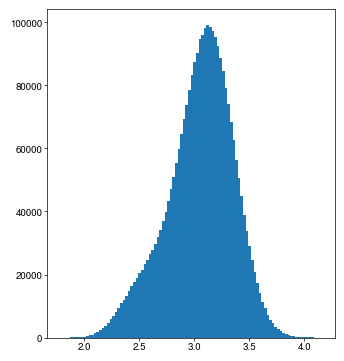

In [32]:
fig, axs = plotter.one_column_plot()

axs.hist(np.log10(fits_df['photons']), 100);
plt.show()

### Multi-file raw data handling

MicroManager splits an OME-TIFF once a single stack exceeds its internal 4 GB limit, so
this acquisition is split into a main file (`..._MMStack_Default.ome.tif`, if present)
plus numbered continuation files (`..._MMStack_Default_1.ome.tif`, etc). The OME-XML that
would normally let `tifffile` stitch these together isn't relied on here (reading with
`is_ome=False`); the helper below groups the files in frame order and translates a global
frame index into the right physical file + local page index, reading only the one frame
Figure 2 actually needs at a time rather than the whole multi-file stack.

Frame-count resolution avoids scanning every file's full IFD chain (slow, especially
under load, on an external drive): it reads the acquisition's *total* frame count from the
MicroManager `metadata.txt` sidecar, scans only the first and last physical file for real,
and only trusts an inferred per-file count for every file in between if the arithmetic
exactly reproduces that recorded total -- otherwise it falls back to scanning every file
for real rather than silently guessing.

In [15]:
_PART_RE = re.compile(r'^(?P<base>.+)_(?P<part>\d+)\.ome\.tif$')
_PAGE_COUNT_CACHE: dict[str, int] = {}


def _n_pages(path):
    key = str(Path(path).resolve())
    if key not in _PAGE_COUNT_CACHE:
        with tifffile.TiffFile(path, is_ome=False) as tf:
            _PAGE_COUNT_CACHE[key] = len(tf.pages)
    return _PAGE_COUNT_CACHE[key]


def _total_frames_from_metadata(folder, base_name):
    """Read Summary.Frames from the MicroManager metadata.txt sidecar, cheaply."""
    meta_files = [
        f for f in os.listdir(folder)
        if f.startswith(base_name) and 'metadata' in f and f.endswith('.txt')
    ]
    if not meta_files:
        return None
    with open(os.path.join(folder, meta_files[0]), 'r', encoding='ISO-8859-1') as f:
        head = f.read(65536)
    m = re.search(r'"Frames"\s*:\s*(\d+)', head)
    return int(m.group(1)) if m else None


def _resolve_page_counts(file_group, total_frames_hint):
    """Determine every file's frame count, serially, with as little scanning as possible."""
    if len(file_group) <= 2:
        for fp in file_group:
            _n_pages(fp)
        return

    t0 = time.time()
    first_n = _n_pages(file_group[0])
    last_n = _n_pages(file_group[-1])
    middle = file_group[1:-1]

    if total_frames_hint is not None:
        remainder = total_frames_hint - first_n - last_n
        if remainder > 0 and remainder % len(middle) == 0:
            per_middle = remainder // len(middle)
            for fp in middle:
                _PAGE_COUNT_CACHE[str(Path(fp).resolve())] = per_middle
            print(f'Inferred {per_middle} pages/file for {len(middle)} middle file(s) from '
                  f'the metadata\'s recorded total ({total_frames_hint} frames) -- skipped '
                  f'scanning them. Done in {time.time() - t0:.1f}s.')
            return
        print(f'Metadata cross-check failed (recorded total={total_frames_hint}, '
              f'first={first_n}, last={last_n}, {len(middle)} middle file(s)) -- '
              f'falling back to scanning every file for real.')

    print(f'Scanning {len(middle)} remaining file(s) for frame counts (one-time cost)...')
    for fp in middle:
        _n_pages(fp)
    print(f'Done in {time.time() - t0:.1f}s.')


def build_file_group(folder, base_name, image_type='.ome.tif'):
    """Order one acquisition's main + numbered continuation files by frame index."""
    all_files = sorted(f for f in os.listdir(folder) if f.endswith(image_type))
    parts = []
    for f in all_files:
        m = _PART_RE.match(f)
        if m and m.group('base') == base_name:
            parts.append((int(m.group('part')), f))
    parts.sort()
    ordered = [base_name + image_type] + [f for _, f in parts]
    return [os.path.join(folder, f) for f in ordered if os.path.isfile(os.path.join(folder, f))]


def read_frame_from_group(file_group, global_frame_idx, dtype=None):
    """Read ONE frame from a (possibly multi-file) acquisition, given a global frame index."""
    offset = 0
    for fp in file_group:
        n = _n_pages(fp)
        if global_frame_idx < offset + n:
            local_idx = global_frame_idx - offset
            with tifffile.TiffFile(fp, is_ome=False) as tf:
                page = tf.pages[local_idx].asarray()
            return page.astype(dtype) if dtype else page
        offset += n
    raise IndexError(f'frame {global_frame_idx} out of range (total {offset} frames)')


FILE_GROUP = build_file_group(DATA_DIR, f'{base_prefix}_MMStack_Default')
print(f'{len(FILE_GROUP)} physical file(s) for this acquisition')
_total_frames_hint = _total_frames_from_metadata(DATA_DIR, f'{base_prefix}_MMStack_Default')
_resolve_page_counts(FILE_GROUP, _total_frames_hint)

12 physical file(s) for this acquisition
Inferred 4456 pages/file for 10 middle file(s) from the metadata's recorded total (50000 frames) -- skipped scanning them. Done in 0.6s.


### Figure 2 — example puncta: raw / weights / fit / residual / spectrum

Rather than re-fitting, pick `N_PUNCTA` individual single-frame localisations directly
from the loaded fits, then re-render everything downstream straight from the raw data:
crop the actual raw frame each fit came from, recompute the photoelectron conversion and
fitting weights, and reconstruct the fitted PSF model from the stored fit parameters
(Gaussian + Bayer mask, using the stored `A_*`/`bg_*` fractions de-normalised by
`photons`/`background_photons` back to absolute units).

In [33]:
# ── Pick N_PUNCTA single-frame localisations that pass a basic quality filter ──
margin = ROI_SIZE / 2
valid_fits = fits_df[
    (fits_df['xc'] > margin) & (fits_df['xc'] < width - margin) &
    (fits_df['yc'] > margin) & (fits_df['yc'] < height - margin)
    & (fits_df['chi_sqr'] < CHI_SQR_MAX)
    & (fits_df['background_photons'] > PHOTON_BG_MIN) & (fits_df['background_photons'] < PHOTON_BG_MAX)
    & (fits_df['photons'] < MAX_PHOTONS_OVERVIEW) & (fits_df['photons'] > MIN_PHOTONS_OVERVIEW)
].reset_index(drop=True)
print(f'{len(valid_fits):,}/{len(fits_df):,} pass the quality filter and have a full '
      f'{ROI_SIZE}x{ROI_SIZE} ROI available')

masks_stacked = M_F.get_stacked_masks(0, 0, width, height, SupRes_F.mosaic_unit)
smoothing_function = types.SimpleNamespace(
    args={'sigma': 1.5}, extent=1.5, smoothing_function=sCMOS.gaussian_filter_stack, data_arg='image',
)

rng = np.random.default_rng(SELECTION_SEED)
chosen_rows = valid_fits.iloc[rng.choice(len(valid_fits), size=N_PUNCTA, replace=False)].reset_index(drop=True)

puncta_all, weights_all, masks_all, coords_all, rows_all = [], [], [], [], []
for _, row in chosen_rows.iterrows():
    xcentre, ycentre = int(round(row['xc'])), int(round(row['yc']))
    xmin, xmax, ymin, ymax = SupRes_F.helper.calculate_roi_bounds(xcentre, ycentre, ROI_SIZE, width, height)

    frame_raw = read_frame_from_group(FILE_GROUP, int(row['frame']), dtype=np.float32)
    raw_roi = frame_raw[ymin:ymax, xmin:xmax]
    pe_roi = IO.convert_to_photoelectrons(
        raw_roi, gain_map=gain_c[ymin:ymax, xmin:xmax], offset_map=offset_c[ymin:ymax, xmin:xmax],
        rqe=rqe_c[ymin:ymax, xmin:xmax],
    )
    smoothed_roi = IO.apply_smoothing(pe_roi, smoothing_function, dtype='float32')
    weights_roi = IO.generate_weights(smoothed_roi, read_noise=readnoise_c[ymin:ymax, xmin:xmax], dtype='float32')
    mask_roi = masks_stacked[ymin:ymax, xmin:xmax, :]

    puncta_all.append(pe_roi)
    weights_all.append(weights_roi)
    masks_all.append(mask_roi)
    coords_all.append((xmin, ymin))
    rows_all.append(row)

237,850/2,885,863 pass the quality filter and have a full 12x12 ROI available


In [34]:
# ── Reconstruct the fitted PSF model + residual for each chosen punctum ────────
# Mask/h5 channel order is B, G, R (np.unique(mosaic_unit), alphabetical). The h5's
# A_*/bg_* columns are normalised fractions (sum to 1); de-normalise back to absolute
# photon-like units using each row's own 'photons'/'background_photons' totals.
x_arr = np.arange(ROI_SIZE, dtype=np.float32)
models, residuals, spectra, xy_local, frame_labels = {}, {}, {}, {}, {}

for k, row in enumerate(rows_all):
    xmin, ymin = coords_all[k]
    xc_local, yc_local = row['xc'] - xmin, row['yc'] - ymin
    s_x, s_y = row['s_x'], row['s_y']

    A_frac = np.array([row['A_B'], row['A_G'], row['A_R']])
    bg_frac = np.array([row['bg_B'], row['bg_G'], row['bg_R']])
    A_abs = A_frac * row['photons']
    bg_abs = bg_frac * row['background_photons']

    gauss2d = np.zeros((ROI_SIZE, ROI_SIZE), dtype=np.float32)
    gauss2d = gaussoptfuncs.gaussian_unscaled_model(gauss2d, x_arr, ROI_SIZE, xc_local, yc_local, s_x, s_y)

    model = np.zeros((ROI_SIZE, ROI_SIZE), dtype=np.float32)
    mask_roi = masks_all[k]
    for c in range(3):
        m = mask_roi[:, :, c]
        model[m] = A_abs[c] * gauss2d[m] + bg_abs[c]

    models[k]       = model
    residuals[k]     = puncta_all[k] - model
    spectra[k]       = A_frac
    xy_local[k]      = (xc_local, yc_local)
    frame_labels[k]  = int(row['frame'])

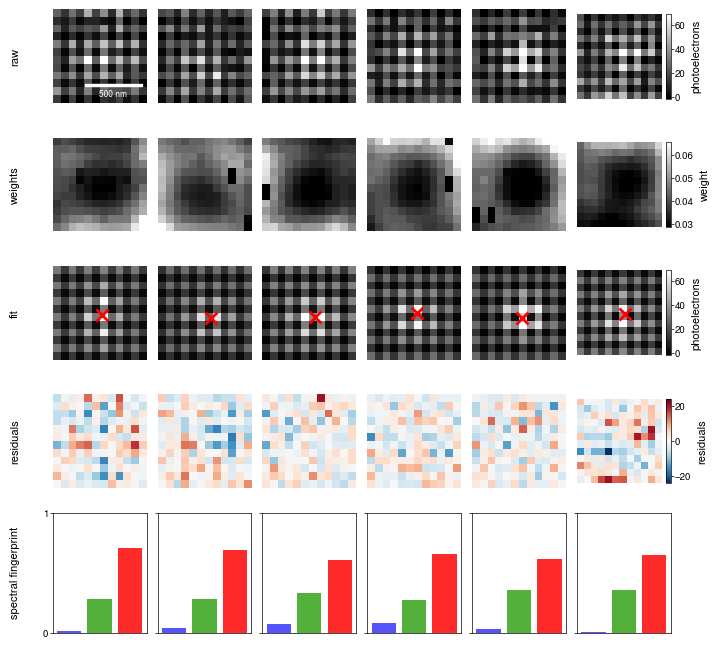

In [35]:
channel_colours = ["#5555ff", "#53b03b", "#ff2a2a"]  # B, G, R -- matches Ternary_Plot_SingleMolecules.ipynb
row_labels = ['raw', 'weights', 'fit', 'residuals', 'spectral fingerprint']

fig, axs = plotter.two_column_plot(nrows=5, ncols=N_PUNCTA, width=6.69, height=6.5)

vmin = np.percentile(puncta_all, 5)
vmax = np.percentile(puncta_all, 99)

vmin_weights = np.percentile(weights_all, 5)
vmax_weights = np.percentile(weights_all, 99)

rmaxes = np.zeros(N_PUNCTA)
for k in range(N_PUNCTA):
    rmaxes[k] = np.max(np.abs(residuals[k]))
rmax = np.max(rmaxes)

for k in range(N_PUNCTA):
    col = k
    raw_roi = puncta_all[k]
    xc_local, yc_local = xy_local[k]

    axs[0, col], _ = plotter.image_plot(
        axs[0, col], raw_roi, vmin=vmin, vmax=vmax, origin='upper',
        scalebar=(col == 0), scalebarsize=500.0, scalebarlabel='500 nm',
        colorbar=(col == 5), colorbar_label='photoelectrons'
    )

    axs[1, col], _ = plotter.image_plot(axs[1, col],
                                        weights_all[k], vmin=vmin_weights, vmax=vmax_weights, cmap='gray', origin='upper',
                                        colorbar=(col == 5), colorbar_label='weight'
                      )
    axs[1, col].set_xticks([]); axs[1, col].set_yticks([])

    axs[2, col], _ = plotter.image_plot(axs[2, col], models[k], vmin=vmin, vmax=vmax, origin='upper',
                                        colorbar=(col == 5), colorbar_label='photoelectrons')
    axs[2, col].plot(xc_local, yc_local, 'rx', markersize=8, markeredgewidth=2)

    axs[3, col], _ = plotter.image_plot(axs[3, col], residuals[k], cmap='RdBu_r', vmin=-rmax, vmax=rmax, origin='upper',
                                       colorbar=(col == 5), colorbar_label='residuals')
    axs[3, col].set_xticks([]); axs[3, col].set_yticks([])

    axs[4, col].bar(np.arange(3), spectra[k], color=channel_colours)
    axs[4, col].set_ylim([0, 1]); axs[4, col].set_xticks([]); axs[4, col].set_yticks([0, 1])
    if col != 0:
        axs[4, col].set_yticklabels('')
    axs[4, col].grid(False)


for row in range(5):
    axs[row, 0].text(-0.35, 0.5, row_labels[row], transform=axs[row, 0].transAxes,
                      fontsize=8, ha='right', va='center', rotation=90)

plotter.save_or_show(fig, save_path=str(FIGURE_DIR / 'example_puncta_raw_weights_fit_residual_spectrum_NR4A_SaureusPAINT.svg'), show=True)